# 📊 Comparaison des modèles Teacher vs Student

Ce notebook compare les performances du modèle DistilBERT fine-tuné (teacher) et du modèle distillé (student) entraîné via knowledge distillation.

### 📦  Chargement des dépendances et configuration

In [1]:
import os
import sys
import time
import psutil
import humanize
import logging
from pathlib import Path

# Reduce TensorFlow log level to warn
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizerFast
import gc
import tensorflow.keras.backend as K

# Ajout du chemin racine du projet pour permettre les imports de modules locaux
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from lucenai.training.model import load_best_model_and_tokenizer
from lucenai.training.distillation import load_student_model_and_tokenizer
from lucenai.config.settings import MODEL_PATHS, TRAINING_PARAMS

# Paramètres d'affichage
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


### 📄 Chargement du dataset de test

In [2]:
try:
    df_test = pd.read_csv("./data/test.csv")
    print(f"✅ Fichier chargé avec succès, Nombre d'échantillons : {len(df_test)}")
    display(df_test.head(10))
except FileNotFoundError:
    print("❌ Erreur : le fichier spécifié est introuvable.")
except pd.errors.EmptyDataError:
    print("❌ Erreur : le fichier est vide.")
except pd.errors.ParserError:
    print("❌ Erreur : échec de l'analyse du fichier.")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")

✅ Fichier chargé avec succès, Nombre d'échantillons : 873


,id,full_text,clean_text,label
0,3698,I liked a @YouTube video https://t.co/zjksIjwl...,i liked a video binance in trouble digix final...,1
1,4955,📷 Bitcoin RAINBOW Light - Exclusively produced...,bitcoin rainbow light exclusively produced for...,1
2,4402,@marchmadness I’d like somebody to check the r...,id like somebody to check the refs paypal bitc...,0
3,761,There’s literally nothing worse than any man n...,theres literally nothing worse than any man no...,0
4,3213,"RT @Blockchainlife: Jack Dorsey, CEO of Twitte...",jack dorsey ceo of twitter and square has come...,0
5,3316,"Without safe 0-conf, BCash it is entirely wort...",without safe 0conf bcash it is entirely worthl...,0
6,4713,Cryptocurrency Technical Analysis &amp; Strate...,cryptocurrency technical analysis strategy bit...,1
7,768,RT @CoinsAirdrops: #Bitcoin #Satoshi #Earn_Mon...,new airdrop 45 stars worth 00,1
8,4369,Bitcoin Set to Go Higher Despite Net-Long Posi...,bitcoin set to go higher despite netlong posit...,1
9,932,Bitnation - have a look at this project! Highl...,bitnation have a look at this project highly r...,1


### 📦 Chargement des modèles Teacher et Student

In [3]:
#  Modèle teacher
teacher_model_path = MODEL_PATHS.best_weights
teacher_tokenizer_path = MODEL_PATHS.best_tokenizer
print(f"📦 Chargement du modèle teacher: {teacher_model_path}")
teacher_model, teacher_tokenizer = load_best_model_and_tokenizer(
    model_path=teacher_model_path,
    tokenizer_path=teacher_tokenizer_path,
)

# Modèles student
student_model_path = MODEL_PATHS.student_weights
student_tokenizer_path = MODEL_PATHS.student_tokenizer 
print(f"\n📦 Chargement du modèle élève: {student_model_path}")
student_model, student_tokenizer = load_student_model_and_tokenizer(
    model_path=student_model_path,
    tokenizer_path=student_tokenizer_path,
)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


📦 Chargement du modèle teacher: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model
📥 Loading tokenizer from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/tokenizer
✅ Tokenizer loaded successfully.
🧠 Rebuilding model architecture...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


🏗️ Building deep architecture...
   ✅ Input layers created
   ✅ DistilBERT integrated
   ✅ [CLS] token extracted
   ✅ Deep classification head added

✅ Model successfully built!
📦 Loading model weights from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model
✅ Weights loaded successfully.

📦 Chargement du modèle élève: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/student_model/checkpoint/weights
📥 Loading tokenizer from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/student_model/tokenizer
✅ Tokenizer loaded successfully.
🧠 Rebuilding student model architecture...
📋 Distilled model detailed architecture
════════════════════════════════════════════════════════════════════════════════
Model: "StudentModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected t

### ✏️ Préparation des données pour l'inférence

In [4]:
# Tokenizer (doit correspondre à celui utilisé lors de l'entraînement)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def encode_texts(texts, max_len=TRAINING_PARAMS.max_len):
    tokens = tokenizer(
        texts.tolist(),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    return tokens

x_test_tokens = encode_texts(df_test["clean_text"])
y_test = df_test["label"].values


### 📊 Empreinte RAM/Disque et temps d'inférence

Fonctions pour comparer l’empreinte mémoire (RAM) et la taille sur disque des modèles Teacher et Student.

In [5]:
def get_model_size(model_dir: str) -> str:
    """
    Retourne l'occupation disque du modele dans un format lisible
    """
    total_size = 0
    for dirpath, _, filenames in os.walk(model_dir):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return humanize.naturalsize(total_size)

def get_ram_usage() -> str:
    """
    Retourne l’utilisation actuelle de la RAM du processus dans un format lisible
    """
    process = psutil.Process(os.getpid())
    ram_bytes = process.memory_info().rss
    return humanize.naturalsize(ram_bytes)

In [6]:
print("👨‍🎓 Inférence modèle Student...")
x_test_inputs = {
    "input_ids": tf.convert_to_tensor(x_test_tokens["input_ids"], dtype=tf.int32),
    "attention_mask": tf.convert_to_tensor(x_test_tokens["attention_mask"], dtype=tf.int32),
}
start_student = time.time()
student_preds = student_model.predict(x_test_inputs, verbose=0).flatten()
end_student = time.time()
student_time = end_student - start_student
student_disk = get_model_size(MODEL_PATHS.student_weights.parent)
student_ram = get_ram_usage()

print("👨‍🏫 Inférence modèle Teacher...")
start_teacher = time.time()
teacher_preds = teacher_model.predict(x_test_inputs, verbose=0).flatten()
end_teacher = time.time()
teacher_time = end_teacher - start_teacher
teacher_disk = get_model_size(MODEL_PATHS.best_weights.parent)
teacher_ram = get_ram_usage()

# 📦 Affichage des ressources
print("\n📦 Ressources utilisées (RAM & Disque) :")
print(f"👨‍🏫 Teacher — Disque : {teacher_disk} | RAM approx. : {teacher_ram}")
print(f"👨‍🎓 Student — Disque : {student_disk} | RAM approx. : {student_ram}")

print("\n📊 Résumé des temps d'inférence :")
print(f"👨‍🏫 Modèle Teacher : {teacher_time:.2f} secondes")
print(f"👨‍🎓 Modèle Student : {student_time:.2f} secondes")
print(f"⚡ Accélération : ×{teacher_time / student_time:.2f} plus rapide (student)")

# Conversion des probabilités en labels binaires
teacher_labels = (teacher_preds >= 0.55).astype(int)
student_labels = (student_preds >= 0.55).astype(int)


👨‍🎓 Inférence modèle Student...
👨‍🏫 Inférence modèle Teacher...



📦 Ressources utilisées (RAM & Disque) :
👨‍🏫 Teacher — Disque : 1.2 GB | RAM approx. : 1.5 GB
👨‍🎓 Student — Disque : 7.8 MB | RAM approx. : 1.3 GB

📊 Résumé des temps d'inférence :
👨‍🏫 Modèle Teacher : 41.98 secondes
👨‍🎓 Modèle Student : 0.14 secondes
⚡ Accélération : ×290.58 plus rapide (student)


### ⚖️ Rapport de classification

In [7]:
print("📘 Teacher model:")
print(classification_report(y_test, teacher_labels))

print("📗 Student model:")
print(classification_report(y_test, student_labels))


📘 Teacher model:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       437
           1       0.94      0.95      0.95       436

    accuracy                           0.95       873
   macro avg       0.95      0.95      0.95       873
weighted avg       0.95      0.95      0.95       873

📗 Student model:
              precision    recall  f1-score   support

           0       0.91      0.55      0.68       437
           1       0.68      0.94      0.79       436

    accuracy                           0.75       873
   macro avg       0.79      0.75      0.74       873
weighted avg       0.79      0.75      0.74       873



### 🔍 Matrices de confusion

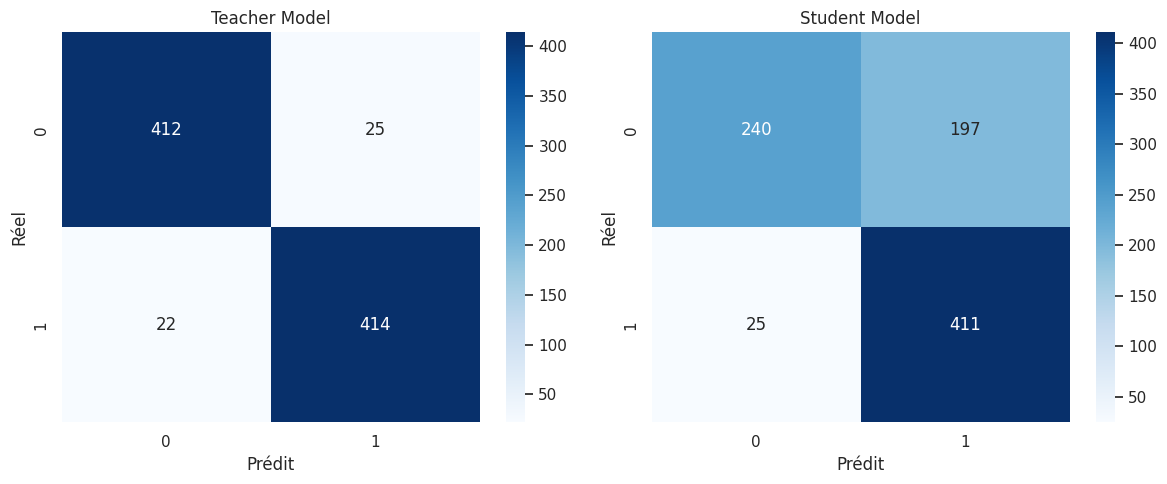

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, title in zip(
    axes,
    [teacher_labels, student_labels],
    ["Teacher Model", "Student Model"]
):
    cm = confusion_matrix(y_test, labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()


## ✅ Comparaison

In [9]:
def parse_mb(value: str) -> float:
    """
    Convertit une chaîne de type '123.45 MB' ou '1.6 GB' en float (MB).
    1 GB = 1024 MB
    """
    value = value.strip().upper()
    if value.endswith("GB"):
        return float(value.replace("GB", "").strip()) * 1024
    elif value.endswith("MB"):
        return float(value.replace("MB", "").strip())
    else:
        raise ValueError(f"Format inconnu pour la taille: {value}")

comparison_df = pd.DataFrame([
    {
        "Model": "Teacher",
        "Inference Time (s)": round(teacher_time, 4),
        "Disk Size (MB)": round(parse_mb(teacher_disk), 2),
        "RAM Usage (MB)": round(parse_mb(teacher_ram), 2),
    },
    {
        "Model": "Student",
        "Inference Time (s)": round(student_time, 4),
        "Disk Size (MB)": round(parse_mb(student_disk), 2),
        "RAM Usage (MB)": round(parse_mb(student_ram), 2),
    }
])

print(comparison_df.to_string(index=False))

  Model  Inference Time (s)  Disk Size (MB)  RAM Usage (MB)
Teacher             41.9795          1228.8          1536.0
Student              0.1445             7.8          1331.2


## 📌 Conclusion :

- Le modèle **Teacher (DistilBERT)** offre des performances de classification très solides, proches de 95% d’accuracy, ce qui en fait un excellent choix pour des environnements puissants (serveurs, cloud).

- Le modèle **Student (distillé)**, bien que moins précis, est extrêmement léger (35× plus petit) et plus rapide. Il est donc idéal pour des scénarios embarqués ou à ressources limitées (mobile, IoT, edge computing).

- La distillation reste utile si l’on peut tolérer une baisse de performance pour un gros gain en efficacité computationnelle.